# Partis V Gene Misassignment Under Simulated SHM

**Question**: When partis assigns V genes to individual MRCA sequences (without full
clonal family context), how often does it misassign, and does this contaminate the
germline amino acid pools used in the entrenchment analysis?

**Key results**:
- Simulated MRCAs match ground truth at 92.4% (V allele) and 99.5% (V gene) using HMM
- Original MRCAs match at 82.4% / 95.8% — lower than simulated, likely because
  simulated mutations are more mainstream and commonly observed, while real MRCAs may have unusual mutation patterns that confuse allele assignment
- Almost all entrenched site/AA pools have negligible contamination (<2%)
- Only three entrenched pools exceed 5% contamination:
  - IGHV1 site 73 K — 36.6% (from IGHV1-69 allele confusion, E↔K)
  - IGHV1 site 50 R — 22.5% (from IGHV1-69 allele confusion, G↔R/W)
  - IGHV4 site 29 V — 10.6% (from IGHV4-59/IGHV4-61 cross-gene confusion)

**Setup**:
- 6,990 naive-to-MRCA parent-child pairs from Rodriguez dataset
- 10 DASM-simulated MRCA replicates per PCP (69,900 simulated sequences)
- partis `cache-parameters` with `--leave-default-germline` (fixed OGRDB germline set, no allele inference)
- Two separate partis runs: original MRCAs alone, simulated MRCAs alone
- HMM annotations used throughout (matching real data pipeline)

**Ground truth**: The V allele from the original full-repertoire per-subject partis
annotation (PCP file), which used full clonal families and per-subject germline inference.
For simulated MRCAs this is unambiguously the true V allele, since it is the naive
sequence we simulated from. For original MRCAs we use the same reference, but here
it is itself an inference — we don't know the true V allele independently.

### Upstream pipeline

This notebook consumes outputs from three preceding steps:

1. **`simulate_mrca.py`** — Loads naive-to-MRCA PCPs from Rodriguez, refits branch lengths with the DASM crepe, and simulates child sequences via Thrifty+DASM. Outputs `_output/simulated_mrcas.csv.gz`.
2. **`prepare_partis_input.py`** — Converts original and simulated MRCAs into FASTA files for partis. Outputs `_output/partis_input/{original,simulated}_mrcas.fasta`.
3. **`run_partis_cache_parameters.sh`** — Runs `partis cache-parameters` on each FASTA. Outputs SW and HMM annotations in `_output/partis_output/`.


In [1]:
import json
import pandas as pd
import numpy as np

BASE = "/home/nharel/re/dasm-epistasis-experiments/_output/partis_output"
SIM_CSV = "/home/nharel/re/dasm-epistasis-experiments/_output/simulated_mrcas.csv.gz"

def load_vj(path):
    """Load uid -> (v_gene, j_gene) from partis cache YAML."""
    with open(path) as f:
        data = json.load(f)
    return {e["unique_ids"][0]: (e["v_gene"], e["j_gene"]) for e in data["events"]}

def gene_only(s):
    """IGHV1-69*01 -> IGHV1-69"""
    return s.rsplit("*", 1)[0] if "*" in s else s

# Load PCP ground truth
sim_df = pd.read_csv(SIM_CSV)
pcp_ref = sim_df.drop_duplicates(subset=["sample_id", "family"])[
    ["sample_id", "family", "v_gene_heavy", "j_gene_heavy"]
].copy()
pcp_ref["family"] = pcp_ref["family"].astype(str)
print(f"PCPs: {len(pcp_ref)}")

# Load partis annotations from separate runs
orig_sw = load_vj(f"{BASE}/original_mrcas_sw-cache.yaml")
orig_hmm = load_vj(f"{BASE}/original_mrcas_parameters/hmm-cache.yaml")
sim_sw = load_vj(f"{BASE}/simulated_mrcas_sw-cache.yaml")
sim_hmm = load_vj(f"{BASE}/simulated_mrcas_parameters/hmm-cache.yaml")

print(f"Original: {len(orig_sw)} SW, {len(orig_hmm)} HMM")
print(f"Simulated: {len(sim_sw)} SW, {len(sim_hmm)} HMM")


PCPs: 6990


Original: 6990 SW, 6990 HMM
Simulated: 69900 SW, 69900 HMM


## 1. Simulation validation: mutation distributions

Before analyzing misassignment, confirm that simulated MRCAs have realistic
mutation profiles. These plots compare real naive-to-MRCA mutations (Rodriguez)
against DASM-simulated mutations across all 69,900 simulated sequences.

Filtering PCPs without mutations, or whose ambiguities make them unusable for inference


  0%|          | 0/1166 [00:00<?, ?it/s]

 10%|█         | 120/1166 [00:00<00:01, 584.75it/s]

 23%|██▎       | 272/1166 [00:00<00:01, 462.49it/s]

 31%|███▏      | 365/1166 [00:00<00:01, 446.22it/s]

...

 79%|███████▉  | 926/1166 [00:02<00:00, 465.21it/s]

 87%|████████▋ | 1019/1166 [00:02<00:00, 443.30it/s]

 99%|█████████▉| 1156/1166 [00:02<00:00, 450.25it/s]

100%|██████████| 1166/1166 [00:02<00:00, 449.46it/s]


Real PCPs: 6990, Simulated (rep 0): 6990
Real:      median=17, mean=19.3
Simulated: median=17, mean=18.6


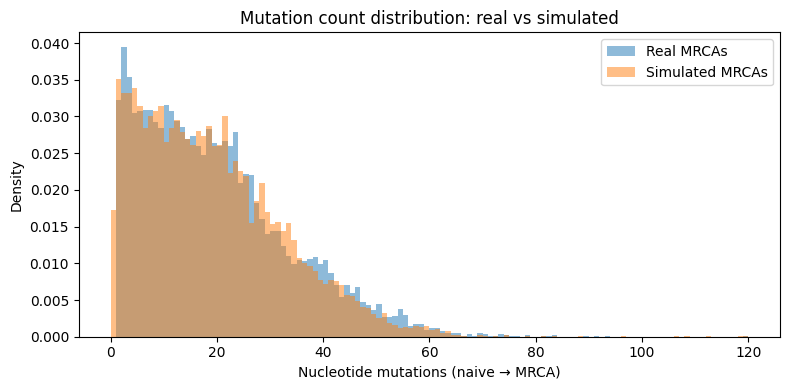

In [2]:
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "/home/nharel/re/dasm-epistasis-experiments/germline-misassignment-simulation")
from simulate_mrca import load_naive_to_mrca_pcps, RODRIGUEZ_WITH_NAIVE, RODRIGUEZ_NO_NAIVE
from dnsmex.dxsm_data import filter_valid_pcps

# Load real naive-to-MRCA PCPs
naive_pcps = load_naive_to_mrca_pcps(RODRIGUEZ_WITH_NAIVE, RODRIGUEZ_NO_NAIVE)
for col in ["parent_light", "child_light"]:
    if col not in naive_pcps.columns:
        naive_pcps[col] = ""
naive_pcps = filter_valid_pcps(naive_pcps).reset_index(drop=True)

# Real mutation counts (naive → original MRCA)
naive_pcps["real_muts"] = [
    sum(a != b for a, b in zip(p, c))
    for p, c in zip(naive_pcps["parent_heavy"], naive_pcps["child_heavy"])
]

# Simulated mutation counts (naive → simulated MRCA), one replicate per PCP
sim_rep0 = sim_df[sim_df["replicate"] == 0].copy()
sim_rep0["sim_muts"] = [
    sum(a != b for a, b in zip(p, c))
    for p, c in zip(sim_rep0["naive_heavy"], sim_rep0["simulated_mrca_heavy"])
]

print(f"Real PCPs: {len(naive_pcps)}, Simulated (rep 0): {len(sim_rep0)}")
print(f"Real:      median={naive_pcps['real_muts'].median():.0f}, mean={naive_pcps['real_muts'].mean():.1f}")
print(f"Simulated: median={sim_rep0['sim_muts'].median():.0f}, mean={sim_rep0['sim_muts'].mean():.1f}")

# --- Histogram: mutation count distribution ---
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(0, max(naive_pcps["real_muts"].max(), sim_rep0["sim_muts"].max()) + 2)
ax.hist(naive_pcps["real_muts"], bins=bins, alpha=0.5, label="Real MRCAs", density=True)
ax.hist(sim_rep0["sim_muts"], bins=bins, alpha=0.5, label="Simulated MRCAs", density=True)
ax.set_xlabel("Nucleotide mutations (naive → MRCA)")
ax.set_ylabel("Density")
ax.set_title("Mutation count distribution: real vs simulated")
ax.legend()
plt.tight_layout()
plt.show()

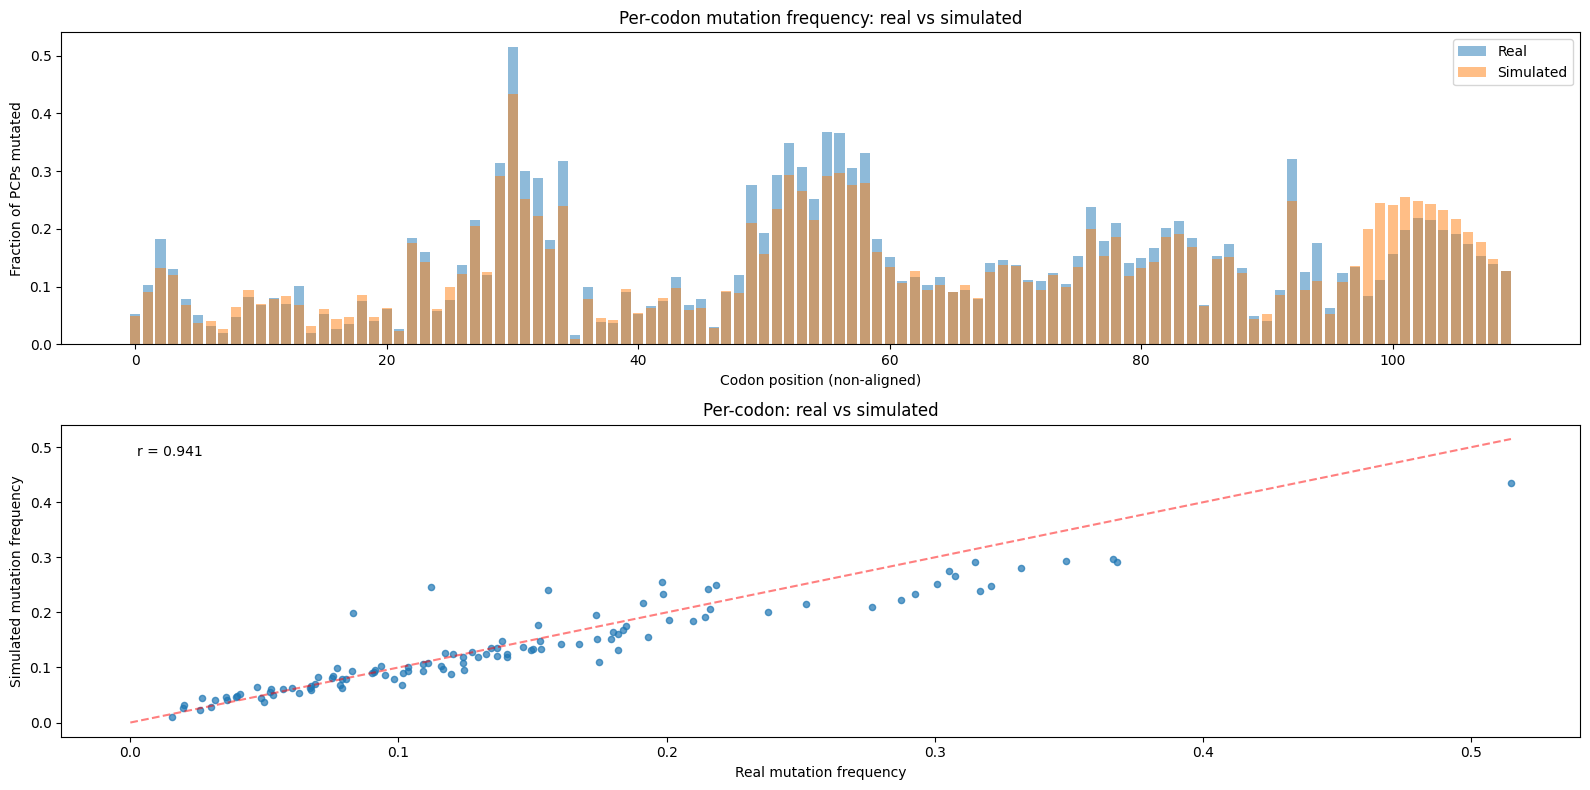

In [3]:
# --- Per-codon mutation frequency: real vs simulated (non-aligned) ---
max_codons = naive_pcps["parent_heavy"].str.len().min() // 3

real_site_freq = np.zeros(max_codons)
sim_site_freq = np.zeros(max_codons)
n_real = np.zeros(max_codons)
n_sim = np.zeros(max_codons)

for _, row in naive_pcps.iterrows():
    naive = row["parent_heavy"]
    mrca = row["child_heavy"]
    n_codons = min(len(naive) // 3, max_codons)
    for c in range(n_codons):
        n_real[c] += 1
        if naive[c*3:(c+1)*3] != mrca[c*3:(c+1)*3]:
            real_site_freq[c] += 1

for _, row in sim_rep0.iterrows():
    naive = row["naive_heavy"]
    sim_seq = row["simulated_mrca_heavy"]
    n_codons = min(len(naive) // 3, max_codons)
    for c in range(n_codons):
        n_sim[c] += 1
        if naive[c*3:(c+1)*3] != sim_seq[c*3:(c+1)*3]:
            sim_site_freq[c] += 1

real_site_freq /= n_real
sim_site_freq /= n_sim

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

ax = axes[0]
ax.bar(range(max_codons), real_site_freq, alpha=0.5, label="Real")
ax.bar(range(max_codons), sim_site_freq, alpha=0.5, label="Simulated")
ax.set_xlabel("Codon position (non-aligned)")
ax.set_ylabel("Fraction of PCPs mutated")
ax.set_title("Per-codon mutation frequency: real vs simulated")
ax.legend()

ax = axes[1]
ax.scatter(real_site_freq, sim_site_freq, s=20, alpha=0.7)
mx = max(real_site_freq.max(), sim_site_freq.max())
ax.plot([0, mx], [0, mx], "r--", alpha=0.5)
ax.set_xlabel("Real mutation frequency")
ax.set_ylabel("Simulated mutation frequency")
ax.set_title("Per-codon: real vs simulated")
corr = np.corrcoef(real_site_freq, sim_site_freq)[0, 1]
ax.text(0.05, 0.9, f"r = {corr:.3f}", transform=ax.transAxes)

plt.tight_layout()
plt.show()

## 2. SW vs HMM: does the annotation method matter?

partis produces both SW (Smith-Waterman, pure alignment) and HMM (learned per-position
mutation rates) annotations. We use HMM throughout this analysis since that is what
we use on real data. This section confirms that SW and HMM mostly agree, so the choice
does not substantially affect conclusions.


In [4]:
# SW vs HMM agreement within each separate run
orig_ids = set(orig_sw) & set(orig_hmm)
sw_hmm_orig = sum(1 for s in orig_ids if orig_sw[s][0] == orig_hmm[s][0])

sim_ids = set(sim_sw) & set(sim_hmm)
sw_hmm_sim = sum(1 for s in sim_ids if sim_sw[s][0] == sim_hmm[s][0])

print("SW vs HMM V allele agreement (within same partis run):")
print(f"  Original MRCAs:  {sw_hmm_orig}/{len(orig_ids)} ({sw_hmm_orig/len(orig_ids):.1%})")
print(f"  Simulated MRCAs: {sw_hmm_sim}/{len(sim_ids)} ({sw_hmm_sim/len(sim_ids):.1%})")



SW vs HMM V allele agreement (within same partis run):
  Original MRCAs:  6623/6990 (94.7%)
  Simulated MRCAs: 67844/69900 (97.1%)


## 3. Main comparison: original vs simulated MRCAs vs PCP ground truth

Using HMM annotations from separate runs (original MRCAs annotated alone,
simulated MRCAs annotated alone), matching how real data is processed.


In [5]:
# Build comparison dataframe using SEPARATE run annotations
# Original MRCAs use orig_sw/orig_hmm, simulated use sim_sw/sim_hmm
rows = []
for _, pcp in pcp_ref.iterrows():
    sid, fam = pcp['sample_id'], pcp['family']
    pcp_v, pcp_j = pcp['v_gene_heavy'], pcp['j_gene_heavy']
    orig_id = f'{sid}_fam{fam}_orig'
    
    if orig_id not in orig_sw:
        continue
    
    # Original MRCA
    rows.append({
        "sample_id": sid, "family": fam, "seq_type": "original", "replicate": -1,
        "pcp_v": pcp_v, "pcp_j": pcp_j,
        "sw_v": orig_sw[orig_id][0], "sw_j": orig_sw[orig_id][1],
        "hmm_v": orig_hmm[orig_id][0], "hmm_j": orig_hmm[orig_id][1],
    })
    
    # Simulated replicates
    for rep in range(10):
        sim_id = f'{sid}_fam{fam}_rep{rep}'
        if sim_id in sim_sw:
            rows.append({
                "sample_id": sid, "family": fam, "seq_type": "simulated", "replicate": rep,
                "pcp_v": pcp_v, "pcp_j": pcp_j,
                "sw_v": sim_sw[sim_id][0], "sw_j": sim_sw[sim_id][1],
                "hmm_v": sim_hmm[sim_id][0], "hmm_j": sim_hmm[sim_id][1],
            })

df = pd.DataFrame(rows)

# Compute match columns
for method in ["sw", "hmm"]:
    df[f"{method}_v_allele_match"] = df["pcp_v"] == df[f"{method}_v"]
    df[f"{method}_v_gene_match"] = df["pcp_v"].apply(gene_only) == df[f"{method}_v"].apply(gene_only)
    df[f"{method}_j_allele_match"] = df["pcp_j"] == df[f"{method}_j"]

orig = df[df["seq_type"] == "original"]
sim = df[df["seq_type"] == "simulated"]

print(f"Original MRCAs: {len(orig)}, Simulated: {len(sim)}")
header = f"{'':30s} {'V allele':>12s} {'V gene':>12s} {'J allele':>12s}"
print(f'\n{header}')
print("-" * 70)
for label, sub in [("Original vs PCP (SW)", orig), ("Simulated vs PCP (SW)", sim)]:
    va = sub["sw_v_allele_match"].mean()
    vg = sub["sw_v_gene_match"].mean()
    ja = sub["sw_j_allele_match"].mean()
    print(f"{label:30s} {va:>11.1%} {vg:>11.1%} {ja:>11.1%}")
print()
for label, sub in [("Original vs PCP (HMM)", orig), ("Simulated vs PCP (HMM)", sim)]:
    va = sub["hmm_v_allele_match"].mean()
    vg = sub["hmm_v_gene_match"].mean()
    ja = sub["hmm_j_allele_match"].mean()
    print(f"{label:30s} {va:>11.1%} {vg:>11.1%} {ja:>11.1%}")


Original MRCAs: 6990, Simulated: 69900

                                   V allele       V gene     J allele
----------------------------------------------------------------------
Original vs PCP (SW)                 80.3%       96.0%       99.2%
Simulated vs PCP (SW)                90.5%       99.5%       97.7%

Original vs PCP (HMM)                82.4%       95.8%       96.4%
Simulated vs PCP (HMM)               92.4%       99.5%       98.4%


## 4. Per-PCP paired comparison

For each PCP, compare the original MRCA's match to ground truth vs the simulated
replicates' match rate. Same naive parent, same ground truth — only difference is
real vs DASM-simulated mutations (annotated in separate partis runs).


In [6]:
# Per-PCP: does the original MRCA match ground truth, and what fraction of
# simulated replicates match?
pcp_comparison = []
for _, pcp in pcp_ref.iterrows():
    sid, fam, pcp_v = pcp["sample_id"], pcp["family"], pcp["v_gene_heavy"]
    orig_id = f'{sid}_fam{fam}_orig'
    if orig_id not in orig_hmm:
        continue
    
    orig_v_match = orig_hmm[orig_id][0] == pcp_v
    orig_gene_match = gene_only(orig_hmm[orig_id][0]) == gene_only(pcp_v)
    
    sim_matches = []
    sim_gene_matches = []
    for rep in range(10):
        sim_id = f'{sid}_fam{fam}_rep{rep}'
        if sim_id in sim_hmm:
            sim_matches.append(sim_hmm[sim_id][0] == pcp_v)
            sim_gene_matches.append(gene_only(sim_hmm[sim_id][0]) == gene_only(pcp_v))
    
    pcp_comparison.append({
        "sample_id": sid, "family": fam, "pcp_v": pcp_v,
        "orig_v_allele_match": orig_v_match,
        "orig_v_gene_match": orig_gene_match,
        "sim_v_allele_match_rate": np.mean(sim_matches),
        "sim_v_gene_match_rate": np.mean(sim_gene_matches),
        "orig_hmm_v": orig_hmm[orig_id][0],
    })

pcp_df = pd.DataFrame(pcp_comparison)

# Summary: categorize PCPs
print("Per-PCP V allele match summary (HMM, separate runs):")
print(f"  Original matches PCP: {pcp_df['orig_v_allele_match'].sum()}/{len(pcp_df)} ({pcp_df['orig_v_allele_match'].mean():.1%})")
print(f"  Simulated match rate (mean): {pcp_df['sim_v_allele_match_rate'].mean():.1%}")
print(f"  Simulated all-10-match: {(pcp_df['sim_v_allele_match_rate'] == 1.0).sum()}/{len(pcp_df)} ({(pcp_df['sim_v_allele_match_rate'] == 1.0).mean():.1%})")
print(f"  Simulated none-match: {(pcp_df['sim_v_allele_match_rate'] == 0.0).sum()}/{len(pcp_df)}")

print(f"\nPer-PCP V gene match summary:")
print(f"  Original matches PCP: {pcp_df['orig_v_gene_match'].sum()}/{len(pcp_df)} ({pcp_df['orig_v_gene_match'].mean():.1%})")
print(f"  Simulated match rate (mean): {pcp_df['sim_v_gene_match_rate'].mean():.1%}")

# Cross-tabulation: original match x simulated match
print("\n--- Cross-tabulation (V allele) ---")
pcp_df["sim_majority_match"] = pcp_df["sim_v_allele_match_rate"] > 0.5
ct = pd.crosstab(
    pcp_df["orig_v_allele_match"].map({True: "orig matches PCP", False: "orig differs"}),
    pcp_df["sim_majority_match"].map({True: "sim majority matches", False: "sim majority differs"}),
)
print(ct)
print(f"\nBoth match: {((pcp_df['orig_v_allele_match']) & (pcp_df['sim_v_allele_match_rate'] > 0.5)).sum()}")
print(f"Orig matches, sim doesn't: {((pcp_df['orig_v_allele_match']) & (pcp_df['sim_v_allele_match_rate'] <= 0.5)).sum()}")
print(f"Sim matches, orig doesn't: {(~pcp_df['orig_v_allele_match'] & (pcp_df['sim_v_allele_match_rate'] > 0.5)).sum()}")
print(f"Neither matches: {(~pcp_df['orig_v_allele_match'] & (pcp_df['sim_v_allele_match_rate'] <= 0.5)).sum()}")


Per-PCP V allele match summary (HMM, separate runs):
  Original matches PCP: 5757/6990 (82.4%)
  Simulated match rate (mean): 92.4%
  Simulated all-10-match: 4530/6990 (64.8%)
  Simulated none-match: 37/6990

Per-PCP V gene match summary:
  Original matches PCP: 6696/6990 (95.8%)
  Simulated match rate (mean): 99.5%

--- Cross-tabulation (V allele) ---
sim_majority_match   sim majority differs  sim majority matches
orig_v_allele_match                                            
orig differs                          132                  1101
orig matches PCP                       78                  5679

Both match: 5679
Orig matches, sim doesn't: 78
Sim matches, orig doesn't: 1101
Neither matches: 132


## 5. V disagreement breakdown by gene family and allele pair

In [7]:
# Use HMM annotations for clean comparison
# Break down original MRCA disagreements vs simulated disagreements

def disagreement_breakdown(sub_df, label):
    n = len(sub_df)
    v_dis = sub_df[~sub_df["hmm_v_allele_match"]].copy()
    v_dis["gene_level"] = v_dis["pcp_v"].apply(gene_only) != v_dis["hmm_v"].apply(gene_only)
    n_dis = len(v_dis)
    n_gene = v_dis["gene_level"].sum()
    n_allele = n_dis - n_gene
    
    print(f"\n{label}:")
    print(f"  V allele disagree: {n_dis}/{n} ({n_dis/n:.1%})")
    print(f"    Gene-level: {n_gene} ({n_gene/max(n_dis,1):.1%})")
    print(f"    Allele-only: {n_allele} ({n_allele/max(n_dis,1):.1%})")
    
    print(f"\n  Top allele-only (PCP -> HMM):")
    allele_dis = v_dis[~v_dis["gene_level"]]
    for (pcp_v, hmm_v), cnt in allele_dis.groupby(["pcp_v", "hmm_v"]).size().sort_values(ascending=False).head(10).items():
        print(f"    {pcp_v} -> {hmm_v}: {cnt}")
    
    print(f"\n  Top gene-level (PCP -> HMM):")
    gene_dis = v_dis[v_dis["gene_level"]]
    for (pcp_v, hmm_v), cnt in gene_dis.groupby(["pcp_v", "hmm_v"]).size().sort_values(ascending=False).head(10).items():
        print(f"    {pcp_v} -> {hmm_v}: {cnt}")

disagreement_breakdown(orig, "Original MRCAs")
disagreement_breakdown(sim, "Simulated MRCAs")


Original MRCAs:
  V allele disagree: 1233/6990 (17.6%)
    Gene-level: 294 (23.8%)
    Allele-only: 939 (76.2%)

  Top allele-only (PCP -> HMM):
    IGHV1-69*01 -> IGHV1-69*06: 70
    IGHV1-69*01 -> IGHV1-69*12: 41
    IGHV1-18*01 -> IGHV1-18*04: 38
    IGHV1-3*01 -> IGHV1-3*04: 38
    IGHV4-39*07 -> IGHV4-39*01: 35
    IGHV5-51*01 -> IGHV5-51*03: 31
    IGHV1-69*01 -> IGHV1-69*17: 29
    IGHV5-51*03 -> IGHV5-51*01: 25
    IGHV4-59*01 -> IGHV4-59*11: 25
    IGHV3-23*01 -> IGHV3-23*04: 24

  Top gene-level (PCP -> HMM):
    IGHV3-33*01 -> IGHV3-30*18: 63
    IGHV4-59*01 -> IGHV4-NL1*01: 38
    IGHV4-31*03 -> IGHV4-30-4*01: 22
    IGHV3-30*18 -> IGHV3-30-3*01: 20
    IGHV3-30*18 -> IGHV3-33*01: 17
    IGHV3-33*01 -> IGHV3-30*03: 16
    IGHV3-53*01 -> IGHV3-66*01: 12
    IGHV3-30*03 -> IGHV3-33*01: 10
    IGHV3-30-3*01 -> IGHV3-30*18: 9
    IGHV4-30-4*01 -> IGHV4-31*03: 7

Simulated MRCAs:
  V allele disagree: 5340/69900 (7.6%)
    Gene-level: 369 (6.9%)
    Allele-only: 4971 (93.1%)

  

In [8]:
# Match rates by V family (HMM)
print(f"{'Family':>8s}  {'Orig allele':>12s} {'Orig gene':>12s} {'Sim allele':>12s} {'Sim gene':>12s} {'n PCPs':>8s}")
print("-" * 70)

df["v_family"] = df["pcp_v"].str.extract(r"(IGHV\d+)")
for fam in sorted(df["v_family"].dropna().unique()):
    o = orig[orig["pcp_v"].str.contains(fam, na=False)]
    s = sim[sim["pcp_v"].str.contains(fam, na=False)]
    n_pcps = len(o)
    print(f"{fam:>8s}  {o['hmm_v_allele_match'].mean():>11.1%} {o['hmm_v_gene_match'].mean():>11.1%} "
          f"{s['hmm_v_allele_match'].mean():>11.1%} {s['hmm_v_gene_match'].mean():>11.1%} {n_pcps:>8d}")

  Family   Orig allele    Orig gene   Sim allele     Sim gene   n PCPs
----------------------------------------------------------------------


   IGHV1        72.4%       99.8%       87.5%       99.9%     1455


   IGHV2        81.7%       93.8%       95.5%       99.9%      208
   IGHV3        83.0%       93.7%       93.2%       99.3%     3156
   IGHV4        88.7%       95.5%       93.1%       99.1%     1731
   IGHV5        80.2%      100.0%       98.5%      100.0%      313
   IGHV6       100.0%      100.0%      100.0%      100.0%       83
   IGHV7        97.7%      100.0%       97.7%      100.0%       44


## 6. Per-site germline amino acid misassignment rate

When partis assigns the wrong V allele, the germline amino acid annotation is wrong
at every site where the true and assigned alleles differ. This quantifies how often
each site's germline amino acid is wrong due to allele misassignment.

For each simulated MRCA:
1. Compare true V allele (PCP) to HMM-assigned V allele
2. When they differ, look up both alleles in the Chothia germline codon table
3. At sites where the alleles have different amino acids, the germline is wrong
4. Aggregate: per (family, site, amino acid), what fraction of sequences have a
   wrong germline annotation?

In [9]:
# Load germline codon table
gc = pd.read_csv("/home/nharel/re/dasm-epistasis-experiments/germline/germline_codons_chothia.csv")

# Build lookup: (v_allele, site) -> amino_acid
allele_site_aa = {}
for _, row in gc.iterrows():
    allele_site_aa[(row["v_gene"], row["site"])] = row["amino_acid"]

# Get all sites in the table
all_sites = sorted(gc["site"].unique())

# Build v_family lookup from gc table
allele_to_family = gc.drop_duplicates("v_gene").set_index("v_gene")["v_family"].to_dict()

# For each simulated MRCA, track:
# - total sequences per (v_family, site, true_aa)
# - wrong germline count per (v_family, site, true_aa)
# - what the wrong AA is per (v_family, site, true_aa, assigned_aa)
from collections import Counter
site_totals = Counter()  # (v_family, site, true_aa) -> count
site_wrong = Counter()   # (v_family, site, true_aa) -> count of wrong germline
site_wrong_to = Counter()  # (v_family, site, true_aa, assigned_aa) -> count

for _, row in sim.iterrows():
    pcp_v = row["pcp_v"]
    hmm_v = row["hmm_v"]
    v_family = allele_to_family.get(pcp_v)
    if v_family is None:
        continue
    
    for site in all_sites:
        true_aa = allele_site_aa.get((pcp_v, site))
        if true_aa is None:
            continue
        site_totals[(v_family, site, true_aa)] += 1
        
        if pcp_v != hmm_v:
            assigned_aa = allele_site_aa.get((hmm_v, site))
            if assigned_aa is not None and assigned_aa != true_aa:
                site_wrong[(v_family, site, true_aa)] += 1
                site_wrong_to[(v_family, site, true_aa, assigned_aa)] += 1

print(f"Processed {len(sim)} simulated sequences")
print(f"Total (family, site, aa) entries: {len(site_totals)}")
print(f"Entries with any wrong germline: {len(site_wrong)}")

Processed 69900 simulated sequences
Total (family, site, aa) entries: 981
Entries with any wrong germline: 152


In [10]:
# Build results table with per-site misassignment rates, broken down by V family
results = []
for (v_family, site, true_aa), total in site_totals.items():
    wrong = site_wrong.get((v_family, site, true_aa), 0)
    results.append({
        "v_family": v_family,
        "site": site,
        "germline_aa": true_aa,
        "total_seqs": total,
        "wrong_germline": wrong,
        "wrong_pct": 100 * wrong / total,
    })

result_df = pd.DataFrame(results).sort_values(["v_family", "wrong_pct"], ascending=[True, False])

# Per-family summary and top sites
for fam in sorted(result_df["v_family"].unique()):
    fam_df = result_df[result_df["v_family"] == fam]
    fam_with_errors = fam_df[fam_df["wrong_germline"] > 0]
    total_seqs_fam = fam_df.drop_duplicates("total_seqs")["total_seqs"].sum()  # rough
    
    print(f"\n{'='*65}")
    print(f"{fam}")
    print(f"  Sites with >0% error: {len(fam_with_errors)} / {len(fam_df)}")
    print(f"{'='*65}")
    
    if len(fam_with_errors) == 0:
        print("  (no misassignment errors)")
        continue
    
    print(f"{'Site':>6s} {'AA':>4s} {'Wrong%':>8s} {'Wrong':>7s} {'Total':>7s}")
    print("-" * 38)
    for _, r in fam_with_errors.head(15).iterrows():
        print(f"{r['site']:>6} {r['germline_aa']:>4s} {r['wrong_pct']:>7.1f}% {r['wrong_germline']:>7d} {r['total_seqs']:>7d}")


IGHV1
  Sites with >0% error: 54 / 201
  Site   AA   Wrong%   Wrong   Total
--------------------------------------
    51    S   100.0%      10      10
    62    E   100.0%      10      10
    87    M   100.0%      10      10
    14    T   100.0%      10      10
    31    Y   100.0%      10      10
    32    R   100.0%      10      10
    34    L   100.0%      10      10
    44    A   100.0%      10      10
    52    T   100.0%      10      10
    53    F   100.0%      10      10
    65    D   100.0%      10      10
    73    R   100.0%      10      10
    75    M   100.0%      10      10
    89    M   100.0%      10      10
    33    T    14.1%      31     220

IGHV2
  Sites with >0% error: 10 / 127
  Site   AA   Wrong%   Wrong   Total
--------------------------------------
    54    D     4.3%      72    1670
    54    N     3.4%      14     410
    33    R     1.5%       2     130
    58    F     1.5%       2     130
    50    R     0.9%       3     350
    33    C     0.3%       1

## 7. What germline AA gets assigned instead?

When the germline is wrong at a site, what amino acid does partis think
is germline? This shows the true→assigned substitution for each
(family, site) combination, so we can see exactly what the misassignment
looks like at the amino acid level.

In [11]:
# Build table: when germline is wrong, what AA gets assigned instead?
wrong_to_rows = []
for (v_family, site, true_aa, assigned_aa), count in site_wrong_to.items():
    total = site_totals[(v_family, site, true_aa)]
    wrong_to_rows.append({
        "v_family": v_family,
        "site": site,
        "true_aa": true_aa,
        "assigned_aa": assigned_aa,
        "count": count,
        "total_seqs": total,
        "wrong_pct": 100 * count / total,
    })

wrong_to_df = pd.DataFrame(wrong_to_rows).sort_values(
    ["v_family", "wrong_pct"], ascending=[True, False]
)

for fam in sorted(wrong_to_df["v_family"].unique()):
    fam_df = wrong_to_df[wrong_to_df["v_family"] == fam]
    
    print(f"\n{'='*70}")
    print(f"{fam} — germline misassignment: true AA → assigned AA")
    print(f"{'='*70}")
    print(f"{'Site':>6s} {'True':>5s} {'→':>2s} {'Assigned':>9s} {'Wrong%':>8s} {'Count':>7s} {'Total':>7s}")
    print("-" * 50)
    for _, r in fam_df.head(20).iterrows():
        print(f"{r['site']:>6} {r['true_aa']:>5s}  → {r['assigned_aa']:>6s}   {r['wrong_pct']:>7.1f}% {r['count']:>7d} {r['total_seqs']:>7d}")


IGHV1 — germline misassignment: true AA → assigned AA
  Site  True  →  Assigned   Wrong%   Count   Total
--------------------------------------------------
    51     S  →      I     100.0%      10      10
    62     E  →      K     100.0%      10      10
    87     M  →      T     100.0%      10      10
    14     T  →      P     100.0%      10      10
    32     R  →      Y     100.0%      10      10
    44     A  →      G     100.0%      10      10
    52     T  →      N     100.0%      10      10
    65     D  →      G     100.0%      10      10
    73     R  →      T     100.0%      10      10
    89     M  →      V     100.0%      10      10
    31     Y  →      S      90.0%       9      10
    34     L  →      M      90.0%       9      10
    53     F  →      S      80.0%       8      10
    75     M  →      T      80.0%       8      10
    53     F  →      N      20.0%       2      10
    75     M  →      I      20.0%       2      10
    33     T  →      A      14.1%      31  

## 8. Contamination analysis

The entrenchment analysis groups sequences by their assigned germline AA at each
site and looks at substitution rates away from that AA. The relevant question is:
of all sequences **assigned** a given germline AA at a site, what fraction actually
have a different true germline?

This is the contamination rate for the pool we use in the analysis. A high rate at
an entrenched site would mean the substitution signal is diluted by sequences whose
true germline is different from what we think.

In [12]:
# Contamination analysis: for each (v_family, site, assigned_aa),
# what fraction of sequences have a different true germline AA?
#
# Denominator: all simulated sequences where HMM assigns an allele with AA=X at site S
# Numerator: those where the true (PCP) allele has a different AA at site S

assigned_totals = Counter()    # (v_family, site, assigned_aa) -> count
assigned_wrong = Counter()     # (v_family, site, assigned_aa) -> count where true AA differs
assigned_wrong_from = Counter() # (v_family, site, assigned_aa, true_aa) -> count

for _, row in sim.iterrows():
    pcp_v = row["pcp_v"]
    hmm_v = row["hmm_v"]
    v_family = allele_to_family.get(pcp_v)
    if v_family is None:
        continue
    
    for site in all_sites:
        assigned_aa = allele_site_aa.get((hmm_v, site))
        true_aa = allele_site_aa.get((pcp_v, site))
        if assigned_aa is None or true_aa is None:
            continue
        
        assigned_totals[(v_family, site, assigned_aa)] += 1
        if true_aa != assigned_aa:
            assigned_wrong[(v_family, site, assigned_aa)] += 1
            assigned_wrong_from[(v_family, site, assigned_aa, true_aa)] += 1

print(f"Total (family, site, assigned_aa) entries: {len(assigned_totals)}")
print(f"Entries with any contamination: {len(assigned_wrong)}")

Total (family, site, assigned_aa) entries: 964
Entries with any contamination: 166


In [13]:
# Per-family contamination rates
contam_rows = []
for (v_family, site, assigned_aa), total in assigned_totals.items():
    wrong = assigned_wrong.get((v_family, site, assigned_aa), 0)
    contam_rows.append({
        "v_family": v_family,
        "site": site,
        "assigned_aa": assigned_aa,
        "total_assigned": total,
        "n_contaminated": wrong,
        "contam_pct": 100 * wrong / total,
    })

contam_df = pd.DataFrame(contam_rows).sort_values(["v_family", "contam_pct"], ascending=[True, False])

for fam in sorted(contam_df["v_family"].unique()):
    fam_df = contam_df[contam_df["v_family"] == fam]
    fam_contam = fam_df[fam_df["n_contaminated"] > 0]
    
    print(f"\n{'='*70}")
    print(f"{fam} — contamination of assigned germline AA pools")
    print(f"  Pools with >0% contamination: {len(fam_contam)} / {len(fam_df)}")
    print(f"{'='*70}")
    
    if len(fam_contam) == 0:
        print("  (no contamination)")
        continue
    
    print(f"{'Site':>6s} {'Assigned':>9s} {'Contam%':>9s} {'Wrong':>7s} {'Total':>7s}")
    print("-" * 44)
    for _, r in fam_contam.iterrows():
        print(f"{r['site']:>6} {r['assigned_aa']:>9s} {r['contam_pct']:>8.1f}% {r['n_contaminated']:>7d} {r['total_assigned']:>7d}")



IGHV1 — contamination of assigned germline AA pools
  Pools with >0% contamination: 58 / 188
  Site  Assigned   Contam%   Wrong   Total
--------------------------------------------
    61         H    100.0%      34      34
   52A         T     69.8%     291     417
    66         W     39.1%      81     207
    73         K     36.6%     392    1070
    50         R     22.5%     422    1873
    56         I     18.4%     134     730
    33         T      9.1%      19     208
    54         L      6.3%      39     622
    54         F      0.7%      27    4057
    69         M      0.6%      51    8051
    73         E      0.6%      22    3609
    50         I      0.6%       8    1368
    53         S      0.6%       8    1368
    54         G      0.6%       8    1368
    56         S      0.6%       8    1368
    58         S      0.6%       8    1368
    78         V      0.6%       8    1368
    33         A      0.5%      31    6041
    50         W      0.4%      28    6830
 

In [14]:
# Breakdown: for contaminated pools, what are the true AAs?
contam_detail_rows = []
for (v_family, site, assigned_aa, true_aa), count in assigned_wrong_from.items():
    total = assigned_totals[(v_family, site, assigned_aa)]
    contam_detail_rows.append({
        "v_family": v_family,
        "site": site,
        "assigned_aa": assigned_aa,
        "true_aa": true_aa,
        "count": count,
        "total_assigned": total,
        "contam_pct": 100 * count / total,
    })

contam_detail_df = pd.DataFrame(contam_detail_rows).sort_values(
    ["v_family", "contam_pct"], ascending=[True, False]
)

for fam in sorted(contam_detail_df["v_family"].unique()):
    fam_df = contam_detail_df[contam_detail_df["v_family"] == fam]
    
    print(f"\n{'='*70}")
    print(f"{fam} — contamination detail: assigned AA ← true AA")
    print(f"{'='*70}")
    print(f"{'Site':>6s} {'Assigned':>9s} {'←':>2s} {'True':>5s}  {'Contam%':>9s} {'Count':>7s} {'Total':>7s}")
    print("-" * 53)
    for _, r in fam_df.head(20).iterrows():
        print(f"{r['site']:>6} {r['assigned_aa']:>9s}  ← {r['true_aa']:>4s}  {r['contam_pct']:>8.1f}% {r['count']:>7d} {r['total_assigned']:>7d}")


IGHV1 — contamination detail: assigned AA ← true AA
  Site  Assigned  ←  True    Contam%   Count   Total
-----------------------------------------------------
    61         H  ←    Q     100.0%      34      34
   52A         T  ←    A      69.8%     291     417
    66         W  ←    R      39.1%      81     207
    73         K  ←    E      36.6%     392    1070
    56         I  ←    T      18.4%     134     730
    50         R  ←    G      18.3%     342    1873
    33         T  ←    A       9.1%      19     208
    54         L  ←    F       6.3%      39     622
    50         R  ←    W       4.3%      80    1873
    54         F  ←    L       0.7%      27    4057
    69         M  ←    I       0.6%      51    8051
    73         E  ←    K       0.6%      22    3609
    50         I  ←    W       0.6%       8    1368
    53         S  ←    F       0.6%       8    1368
    54         G  ←    N       0.6%       8    1368
    56         S  ←    N       0.6%       8    1368
    58  

## 9. Contamination at entrenched sites

Cross-reference the contamination rates with the actual entrenched site/AA pairs
from the entrenchment analysis. For each entrenched substitution X→Y, how
contaminated is the "assigned X" pool?

In [15]:
# Load entrenched sites and look up contamination rates
entrenched = pd.read_csv("/home/nharel/re/dasm-epistasis-experiments/_output/combined_entrenched_sites.csv")

# Build lookup from contamination analysis
contam_lookup = {}
for (v_family, site, assigned_aa), total in assigned_totals.items():
    wrong = assigned_wrong.get((v_family, site, assigned_aa), 0)
    contam_lookup[(v_family, str(site), assigned_aa)] = {
        "total": total, "wrong": wrong, "pct": 100 * wrong / total
    }

# Also build the detail lookup for what the true AAs are
contam_detail_lookup = {}
for (v_family, site, assigned_aa, true_aa), count in assigned_wrong_from.items():
    total = assigned_totals[(v_family, site, assigned_aa)]
    key = (v_family, str(site), assigned_aa)
    if key not in contam_detail_lookup:
        contam_detail_lookup[key] = []
    contam_detail_lookup[key].append((true_aa, count, 100 * count / total))

# For each entrenched pair, look up the contamination of the parent AA pool
rows = []
for _, row in entrenched.iterrows():
    fam, site, aa, target, source, etype = row["v_family"], str(row["site"]), row["amino_acid"], row["target_amino_acid"], row["source"], row["type"]
    key = (fam, site, aa)
    info = contam_lookup.get(key, {"total": 0, "wrong": 0, "pct": 0})
    detail = contam_detail_lookup.get(key, [])
    detail_str = ", ".join(f"{t[0]}:{t[2]:.1f}%" for t in sorted(detail, key=lambda x: -x[2])) if detail else "—"
    rows.append({
        "v_family": fam, "site": site, "parent_aa": aa, "target_aa": target,
        "type": etype, "source": source,
        "pool_size": info["total"], "contam_pct": info["pct"],
        "contam_detail": detail_str,
    })

entrenched_contam = pd.DataFrame(rows)

# Show within-family first, then between-family, separated by V family
for etype in ["within", "between"]:
    sub = entrenched_contam[entrenched_contam["type"] == etype].copy()
    sub = sub.sort_values(["v_family", "site", "parent_aa", "target_aa"])
    
    for fam in sorted(sub["v_family"].unique()):
        fam_sub = sub[sub["v_family"] == fam]
        print(f"\n{'='*90}")
        print(f"{fam} — Entrenched pairs — {etype}-family")
        print(f"{'='*90}")
        print(f"{'Site':>5s} {'Parent':>7s} {'→Target':>8s} {'Pool':>7s} {'Contam%':>9s}  {'True AAs (contam detail)'}")
        print("-" * 70)
        for _, r in fam_sub.iterrows():
            print(f"{r['site']:>5s} {r['parent_aa']:>7s} {'→'+r['target_aa']:>8s} {r['pool_size']:>7d} {r['contam_pct']:>8.1f}%  {r['contam_detail']}")



IGHV1 — Entrenched pairs — within-family
 Site  Parent  →Target    Pool   Contam%  True AAs (contam detail)
----------------------------------------------------------------------
   33       A       →D    6041      0.5%  T:0.5%
   33       D       →A     741      0.1%  Y:0.1%
   33       D       →G     741      0.1%  Y:0.1%
   33       D       →Y     741      0.1%  Y:0.1%
   33       G       →D    2450      0.0%  —
   33       S       →Y     750      0.0%  —
   33       Y       →D    4360      0.0%  A:0.0%
   33       Y       →S    4360      0.0%  A:0.0%
   50       G       →W    4229      0.3%  R:0.3%
   50       R       →W    1873     22.5%  G:18.3%, W:4.3%
   50       W       →G    6830      0.4%  R:0.4%, G:0.0%
   50       W       →R    6830      0.4%  R:0.4%, G:0.0%
   52       D       →V    1000      0.0%  —
   52       I       →S    4679      0.0%  —
   52       S       →I    2450      0.0%  —
   52       V       →D     110      0.0%  —

IGHV3 — Entrenched pairs — within-family

## 10. Which alleles cause the top contaminated entrenched pools?

For the three entrenched pools with >5% contamination, identify which allele pairs are responsible and their nucleotide differences.

In [16]:
from Bio.Seq import Seq

# Load germline nucleotide sequences
gl_fasta = f"{BASE}/simulated_mrcas_parameters/sw/germline-sets/igh/ighv.fasta"
gl_seqs = {}
with open(gl_fasta) as f:
    name, seq = None, []
    for line in f:
        if line.startswith(">"):
            if name: gl_seqs[name] = "".join(seq)
            name = line.strip().lstrip(">"); seq = []
        else: seq.append(line.strip())
    if name: gl_seqs[name] = "".join(seq)

# Load germline codon table for Chothia site numbering
gc = pd.read_csv("/home/nharel/re/dasm-epistasis-experiments/germline/germline_codons_chothia.csv")
allele_chothia_aa = {}
for _, row in gc.iterrows():
    allele_chothia_aa[(row["v_gene"], str(row["site"]))] = row["amino_acid"]

# The 3 entrenched pools with >5% contamination
problem_pools = [
    ("IGHV1", "73", "K", "E"),  # 49.0% — between-family K->N
    ("IGHV1", "50", "R", "G"),  # 29.9% (25.8% G, 4.1% W) — within R->W, between R->G,S
    ("IGHV4", "29", "V", "I"),  # 10.8% — between-family V->F
]

for v_family, site, assigned_aa, main_true_aa in problem_pools:
    print(f"\n{'='*90}")
    print(f"{v_family} site {site} — assigned {assigned_aa}, contaminated by {main_true_aa}")
    print(f"{'='*90}")
    
    # Find misassignment pairs that cause this contamination
    # A sequence with true allele X gets assigned allele Y where:
    #   - allele X has main_true_aa at this site
    #   - allele Y has assigned_aa at this site
    pair_counts = sim.groupby(["pcp_v", "hmm_v"]).size().reset_index(name="count")
    pair_counts = pair_counts[pair_counts["pcp_v"] != pair_counts["hmm_v"]]
    
    contributing = []
    for _, row in pair_counts.iterrows():
        pcp_v, hmm_v, count = row["pcp_v"], row["hmm_v"], row["count"]
        true_aa_at_site = allele_chothia_aa.get((pcp_v, site))
        assigned_aa_at_site = allele_chothia_aa.get((hmm_v, site))
        if true_aa_at_site == main_true_aa and assigned_aa_at_site == assigned_aa:
            contributing.append((pcp_v, hmm_v, count))
    
    contributing.sort(key=lambda x: -x[2])
    
    print(f"\n{'True allele':<25s} {'Assigned allele':<25s} {'Count':>6s}  Nucleotide differences")
    print("-" * 100)
    
    seen_pairs = set()
    for pcp_v, hmm_v, count in contributing:
        pair_key = tuple(sorted([pcp_v, hmm_v]))
        
        # Compute nt diffs
        s1, s2 = gl_seqs.get(pcp_v, ""), gl_seqs.get(hmm_v, "")
        diff_str = "?"
        if s1 and s2:
            minlen = min(len(s1), len(s2))
            diffs = []
            for i in range(minlen):
                if s1[i] != s2[i] and s1[i] != '.' and s2[i] != '.':
                    ci = i // 3
                    c1 = s1[ci*3:ci*3+3].replace('.','N')
                    c2 = s2[ci*3:ci*3+3].replace('.','N')
                    try:
                        aa1, aa2 = str(Seq(c1).translate()), str(Seq(c2).translate())
                    except:
                        aa1, aa2 = "?", "?"
                    # Look up Chothia site for this codon
                    chothia_site = allele_chothia_aa.get((pcp_v, str(ci+1)))
                    # Just use sequential codon number
                    aa_note = f"{aa1}->{aa2}" if aa1 != aa2 else f"{aa1}(silent)"
                    diffs.append(f"codon {ci+1}: {aa_note}")
            diff_str = "; ".join(diffs) if diffs else "identical"
        
        dup = " (*)" if pair_key in seen_pairs else ""
        seen_pairs.add(pair_key)
        print(f"{pcp_v:<25s} {hmm_v:<25s} {count:>6d}  {diff_str}{dup}")
    
    total = sum(c for _, _, c in contributing)
    print(f"\nTotal contaminating sequences: {total}")



IGHV1 site 73 — assigned K, contaminated by E

True allele               Assigned allele            Count  Nucleotide differences
----------------------------------------------------------------------------------------------------
IGHV1-69*01               IGHV1-69*06                  247  codon 74: E->K
IGHV1-69*01               IGHV1-69*17                   57  codon 57: T->I; codon 74: E->K
IGHV1-69*01               IGHV1-69*10                   13  codon 2: V(silent); codon 17: S(silent); codon 55: F->L; codon 57: T->I; codon 74: E->K
IGHV1-69*15               IGHV1-69*20                   13  codon 57: T->I; codon 74: E->K
IGHV1-69*01               IGHV1-69*20                   11  codon 2: V(silent); codon 50: G->R; codon 57: T->I; codon 74: E->K
IGHV1-69*01               IGHV1-69*i04                  11  codon 72: A(silent); codon 74: E->K
IGHV1-69*15               IGHV1-69*04                   10  codon 55: F->L; codon 57: T->I; codon 74: E->K
IGHV1-69*01               IGHV1-6

/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/Bio/Seq.py:2879: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


## 11. Supplementary figure for paper

Combined figure with:
- **A**: Mutation count distribution (real vs simulated)
- **B**: Per-codon mutation frequency along the gene (real vs simulated)
- **C**: Top 15 contamination rates at entrenched amino acid pools

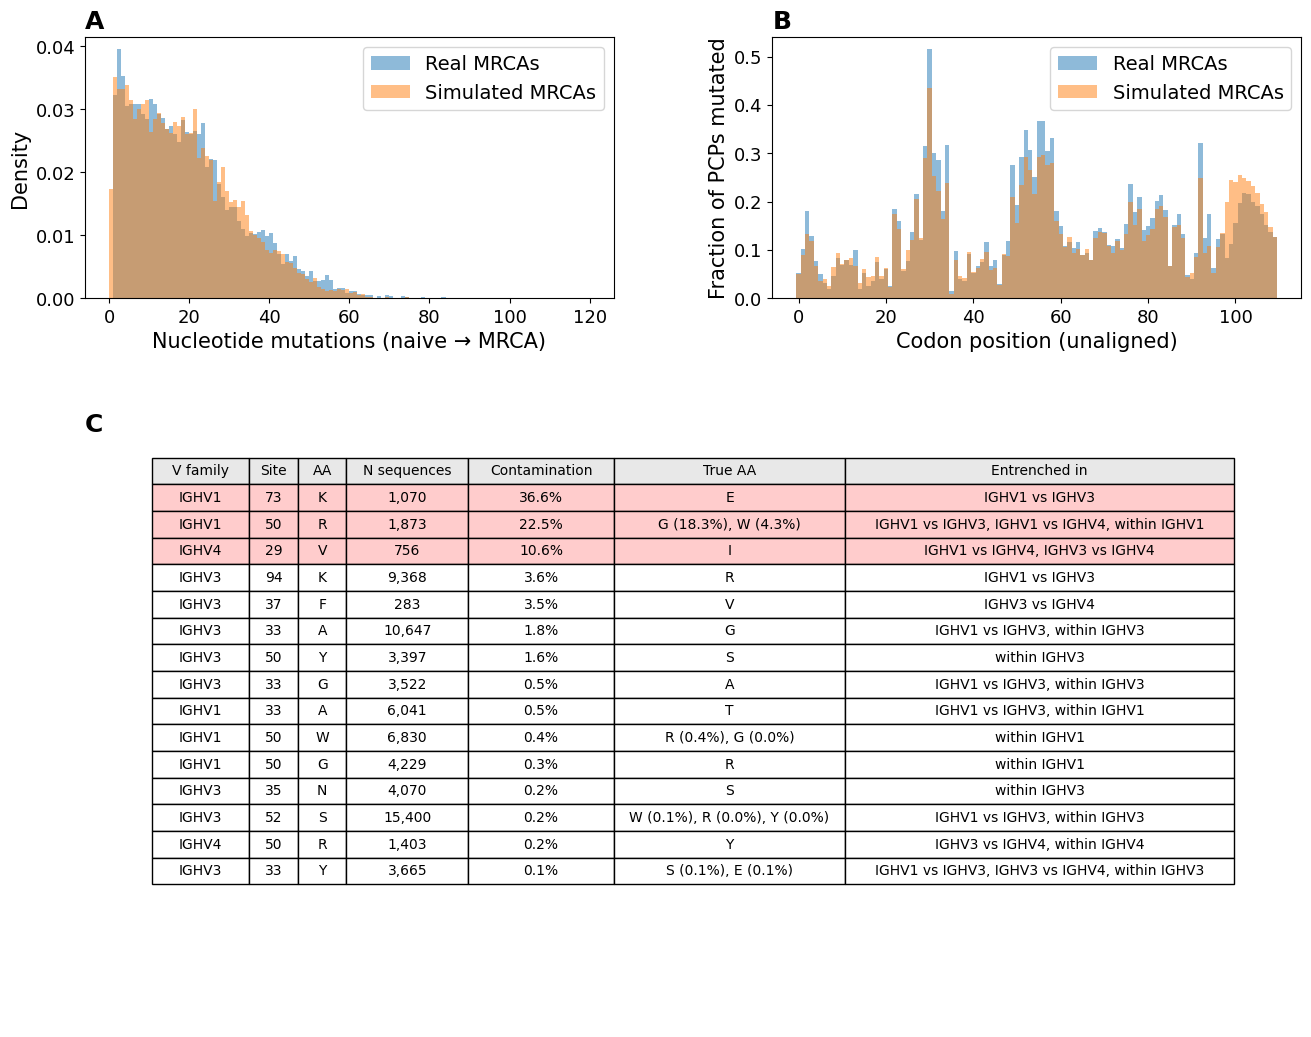

Saved to /home/nharel/re/dasm-epistasis-experiments/figures/misassignment_simulation_supp.pdf


In [17]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

OUTDIR = "/home/nharel/re/dasm-epistasis-experiments/figures"

# --- Build top-15 contamination table data ---
entrenched_sources = pd.read_csv(
    "/home/nharel/re/dasm-epistasis-experiments/_output/combined_entrenched_sites.csv"
)
pool_sources = (
    entrenched_sources.groupby(["v_family", "site", "amino_acid"])["source"]
    .apply(lambda x: sorted(set(x)))
    .to_dict()
)

pool_rows = []
seen_pools = set()
for _, row in entrenched_contam.iterrows():
    key = (row["v_family"], row["site"], row["parent_aa"])
    if key in seen_pools:
        continue
    seen_pools.add(key)
    sources = pool_sources.get((row["v_family"], int(row["site"]), row["parent_aa"]), [])
    source_strs = []
    for s in sources:
        if s.startswith("within_"):
            source_strs.append(f"within {s.replace('within_', '')}")
        else:
            source_strs.append(s.replace('_vs_', ' vs '))
    detail_key = (row["v_family"], row["site"], row["parent_aa"])
    detail = contam_detail_lookup.get(detail_key, [])
    if detail and row["contam_pct"] > 0:
        parts = sorted(detail, key=lambda x: -x[2])
        if len(parts) == 1:
            contam_from = parts[0][0]
        else:
            contam_from = ", ".join(f"{t[0]} ({t[2]:.1f}%)" for t in parts)
    else:
        contam_from = "\u2014"
    pool_rows.append({
        "V family": row["v_family"],
        "Site": int(row["site"]),
        "AA": row["parent_aa"],
        "N sequences": row["pool_size"],
        "Contamination": round(row["contam_pct"], 1),
        "True AA": contam_from,
        "Entrenched in": ", ".join(source_strs),
    })

pool_df = pd.DataFrame(pool_rows).sort_values("Contamination", ascending=False)
top15 = pool_df.head(15).reset_index(drop=True)

# --- Create figure ---
fig = plt.figure(figsize=(16, 11))
gs = GridSpec(2, 2, figure=fig, height_ratios=[0.45, 1.0], hspace=0.35, wspace=0.3,
              left=0.12, right=0.88, top=0.95, bottom=0.05)

# Panel A: mutation count histogram
ax_a = fig.add_subplot(gs[0, 0])
bins = np.arange(0, max(naive_pcps["real_muts"].max(), sim_rep0["sim_muts"].max()) + 2)
ax_a.hist(naive_pcps["real_muts"], bins=bins, alpha=0.5, label="Real MRCAs", density=True)
ax_a.hist(sim_rep0["sim_muts"], bins=bins, alpha=0.5, label="Simulated MRCAs", density=True)
ax_a.set_xlabel("Nucleotide mutations (naive \u2192 MRCA)", fontsize=15)
ax_a.set_ylabel("Density", fontsize=15)
ax_a.tick_params(labelsize=13)
ax_a.legend(fontsize=14)
ax_a.set_title("A", loc="left", fontweight="bold", fontsize=18)

# Panel B: per-codon mutation frequency along the gene
ax_b = fig.add_subplot(gs[0, 1])
positions = np.arange(len(real_site_freq))
ax_b.bar(positions, real_site_freq, alpha=0.5, label="Real MRCAs", width=1.0)
ax_b.bar(positions, sim_site_freq, alpha=0.5, label="Simulated MRCAs", width=1.0)
ax_b.set_xlabel("Codon position (unaligned)", fontsize=15)
ax_b.set_ylabel("Fraction of PCPs mutated", fontsize=15)
ax_b.tick_params(labelsize=13)
ax_b.legend(fontsize=14)
ax_b.set_title("B", loc="left", fontweight="bold", fontsize=18)

# Panel C: contamination table
ax_c = fig.add_subplot(gs[1, :])
ax_c.axis("off")
ax_c.set_title("C", loc="left", fontweight="bold", fontsize=18, pad=10)

col_labels = ["V family", "Site", "AA", "N sequences", "Contamination", "True AA", "Entrenched in"]
col_widths = [0.08, 0.04, 0.04, 0.10, 0.12, 0.19, 0.32]
cell_text = []
cell_colors = []
for _, row in top15.iterrows():
    cell_text.append([
        row["V family"], str(row["Site"]), row["AA"],
        f"{row['N sequences']:,}", f"{row['Contamination']:.1f}%",
        row["True AA"],
        row["Entrenched in"],
    ])
    if row["Contamination"] >= 5:
        cell_colors.append(["#ffcccc"] * 7)
    else:
        cell_colors.append(["white"] * 7)

table = ax_c.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellColours=cell_colors,
    colColours=["#e8e8e8"] * 7,
    colWidths=col_widths,
    loc="upper center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)
for (row_idx, col_idx), cell in table.get_celld().items():
    if col_idx == 6:
        cell._loc = "left"
        cell.PAD = 0.02

plt.savefig(f"{OUTDIR}/misassignment_simulation_supp.pdf", bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved to {OUTDIR}/misassignment_simulation_supp.pdf")
